# 상권 유형별 팝업 스토어 추천 시스템

> **서울 지하철 승하차 패턴**으로 역 주변 상권을 분류하고, **브랜드 카테고리별 최적 입지를 추천**하는 데이터 분석 프로젝트

---

## 프로젝트 배경

팝업 스토어는 짧은 운영 기간 안에 명확한 타겟에게 도달해야 성공한다. 그러나 입지 선정은 여전히 **"감"과 "경험"**에 의존하는 경우가 많다.

이 프로젝트는 **서울 지하철 시간대별 승하차 데이터**라는 객관적 지표로 상권의 성격을 분류하고, 브랜드 카테고리별로 적합한 역을 추천하는 시스템을 만든다.

## 핵심 가설

> 지하철역의 **출퇴근 시간대 승하차 패턴**은 그 역 주변 상권의 성격(주거/오피스/복합)을 반영한다.

- **주거지역**: 아침에 사람들이 떠나고(승차↑), 저녁에 돌아온다(하차↑)
- **오피스지역**: 아침에 사람들이 모이고(하차↑), 저녁에 흩어진다(승차↑)  
- **복합지역**: 두 패턴이 균형

## 데이터

| 데이터 | 출처 | 기간 |
|---|---|---|
| 서울 지하철 시간대별 승하차 인원 | 서울교통공사 | 2021년 6월 |
| 지하철역 좌표 | 위치 데이터셋 | - |

## 분석 흐름

1. 데이터 로드 & 전처리
2. EDA (탐색적 데이터 분석)
3. 주거지수 기반 상권 분류
4. 분류 결과 검증 & 지도 시각화
5. 브랜드 카테고리별 추천 시스템 구축
6. 추천 결과 데모

## 최종 산출물

`recommend("패션/뷰티")` 함수 호출 한 줄로 해당 카테고리에 가장 적합한 지하철역 TOP N을 받아볼 수 있는 추천 엔진

## 1. 환경 설정

분석에 필요한 라이브러리를 불러오고, **한글 폰트**와 **시각화 스타일**을 설정한다.

> ⚠️ **한글 폰트 안내**  
> 아래 셀은 OS를 자동 감지해 한글 폰트 파일을 직접 등록합니다. Colab/Linux에서 폰트가 없으면 `fonts-nanum`을 자동 설치합니다.  
> 만약 한글이 ▢로 보인다면: ① 셀을 다시 실행하거나 ② 런타임/커널을 재시작 후 처음부터 실행하세요.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import folium
import re, os, platform, subprocess, sys
import warnings
warnings.filterwarnings("ignore")

# ── 한글 폰트 설정 (파일 경로 직접 등록 방식) ────────────
# rcParams['font.family']에 이름만 넣는 방식은 폰트 캐시 갱신이 안 되면
# 글자가 ▢로 나옴. fm.fontManager.addfont()로 폰트 파일을 직접 등록해야 안전.

def setup_korean_font():
    system = platform.system()
    
    # OS별 한글 폰트 파일 후보 경로
    candidates = []
    if system == "Darwin":  # macOS
        candidates = [
            "/System/Library/Fonts/AppleSDGothicNeo.ttc",
            "/Library/Fonts/AppleGothic.ttf",
        ]
    elif system == "Windows":
        candidates = [
            "C:/Windows/Fonts/malgun.ttf",
            "C:/Windows/Fonts/malgunbd.ttf",
        ]
    else:  # Linux / Colab
        candidates = [
            "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
            "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
            "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
        ]
    
    # 1) 후보 경로에서 찾기
    font_path = next((p for p in candidates if os.path.exists(p)), None)
    
    # 2) 시스템 전체 검색 (이름 기반 fallback)
    if not font_path:
        for f in fm.findSystemFonts():
            name_lower = os.path.basename(f).lower()
            if any(k in name_lower for k in ["nanumgothic", "malgun", "applegothic", "notosanscjk"]):
                font_path = f
                break
    
    # 3) Colab/Linux에서 폰트가 아예 없으면 자동 설치 시도
    if not font_path and system == "Linux":
        print("⚠ 한글 폰트가 없습니다. Nanum 폰트 자동 설치를 시도합니다...")
        try:
            subprocess.run(
                ["apt-get", "install", "-y", "fonts-nanum"],
                check=True, capture_output=True, timeout=120
            )
            font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
            if not os.path.exists(font_path):
                font_path = None
        except Exception as e:
            print(f"자동 설치 실패: {e}")
            print("수동 설치: !apt-get install -y fonts-nanum")
    
    if not font_path:
        print("⚠ 한글 폰트를 찾을 수 없습니다. 글자가 ▢로 표시됩니다.")
        return None
    
    # 4) 폰트 매니저에 직접 등록 (핵심!)
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
    
    # 5) rcParams 적용
    plt.rcParams["font.family"] = font_name
    plt.rcParams["axes.unicode_minus"] = False
    
    return font_name, font_path

result = setup_korean_font()
if result:
    selected_font, selected_path = result
    print(f"✓ 한글 폰트 등록 완료")
    print(f"  이름: {selected_font}")
    print(f"  경로: {selected_path}")
else:
    selected_font = None

✓ 한글 폰트 등록 완료
  이름: Noto Sans CJK JP
  경로: /usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc


In [2]:
# ── 시각화 스타일 (페이퍼톤 + 카테고리 색상) ──────────
PAPER_BG = "#F7F5EF"   # 따뜻한 종이톤
TEXT     = "#2A2A2A"

COLOR = {
    "주거":   "#5B9279",   # 차분한 그린
    "오피스": "#4A6FA5",   # 침착한 블루
    "복합":   "#D4A24C",   # 따뜻한 오렌지
}

sns.set_theme(style="whitegrid", rc={
    "axes.facecolor": PAPER_BG,
    "figure.facecolor": PAPER_BG,
    "axes.edgecolor": TEXT,
    "axes.labelcolor": TEXT,
    "xtick.color": TEXT, "ytick.color": TEXT,
    "axes.spines.top": False, "axes.spines.right": False,
})

# seaborn set_theme이 폰트를 덮어쓰므로 다시 적용
if selected_font:
    plt.rcParams["font.family"] = selected_font
    plt.rcParams["axes.unicode_minus"] = False

## 2. 데이터 로드

- **승하차 데이터**: `cp949` 인코딩 (서울교통공사 원본)
- **위치 데이터**: `utf-8` 인코딩

In [3]:
RIDE_PATH = "Seoul_subway_data_20210705.csv"
LOC_PATH  = "subway_location_data.csv"

ride = pd.read_csv(RIDE_PATH, encoding="cp949")
loc  = pd.read_csv(LOC_PATH,  encoding="utf-8")

print(f"승하차 데이터: {ride.shape[0]:,}행 × {ride.shape[1]}열")
print(f"위치 데이터:   {loc.shape[0]:,}행 × {loc.shape[1]}열")
print(f"\n승하차 데이터 기간: {ride['사용월'].min()} ~ {ride['사용월'].max()}")
ride.head(3)

승하차 데이터: 45,338행 × 52열
위치 데이터:   579행 × 4열

승하차 데이터 기간: 201501 ~ 202106


,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,23시-24시 하차인원,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원,작업일자
0,202106,1호선,동대문,715,14,13235,2131,8936,6979,14776,...,8211,16,1434,1,1,0,0,0,0,20210703
1,202106,1호선,동묘앞,51,1,3218,1100,3422,4802,5896,...,2589,4,1348,0,0,0,0,0,0,20210703
2,202106,1호선,서울역,654,17,9008,6400,12474,37203,37253,...,8024,30,637,0,1,0,0,0,0,20210703


## 3. 데이터 전처리

### 처리 과정
1. **2021년 6월 데이터만 필터링** (분석 시점 기준)
2. **환승역 통합**: 같은 역명이 여러 호선에 분산되어 있으므로 합산
3. **시간대 통계 계산**: 출퇴근 시간대 승하차 인원 추출
4. **위치 데이터 조인**: 역명 정규화 후 좌표 결합

In [4]:
# 1) 2021년 6월 필터링
ride_jun = ride[ride["사용월"] == 202106].copy()

# 2) 환승역 통합 (같은 역명/다른 호선 합산)
board_cols  = [c for c in ride.columns if "승차인원" in c]
alight_cols = [c for c in ride.columns if "하차인원" in c]

agg = {c: "sum" for c in board_cols + alight_cols}
stations = ride_jun.groupby("지하철역", as_index=False).agg(agg)

# 호선 정보는 별도로 보존 (예: "잠실(송파구청)" → "2호선, 8호선")
line_info = (ride_jun.groupby("지하철역")["호선명"]
             .apply(lambda x: ", ".join(sorted(set(x)))).reset_index())
stations = stations.merge(line_info, on="지하철역")

print(f"전체 역 수: {len(stations)}개 (환승역 통합 완료)")

전체 역 수: 520개 (환승역 통합 완료)


In [5]:
# 3) 출퇴근 시간대 집계
# 출근시간: 07-09시 / 퇴근시간: 18-20시 (러시아워 정의)
MORNING_BOARD  = ["07시-08시 승차인원", "08시-09시 승차인원"]
MORNING_ALIGHT = ["07시-08시 하차인원", "08시-09시 하차인원"]
EVENING_BOARD  = ["18시-19시 승차인원", "19시-20시 승차인원"]
EVENING_ALIGHT = ["18시-19시 하차인원", "19시-20시 하차인원"]

stations["출근_승차"] = stations[MORNING_BOARD].sum(axis=1)
stations["출근_하차"] = stations[MORNING_ALIGHT].sum(axis=1)
stations["퇴근_승차"] = stations[EVENING_BOARD].sum(axis=1)
stations["퇴근_하차"] = stations[EVENING_ALIGHT].sum(axis=1)
stations["총인원"]    = stations[board_cols + alight_cols].sum(axis=1)

stations[["지하철역","호선명","출근_승차","출근_하차","퇴근_승차","퇴근_하차","총인원"]].head()

,지하철역,호선명,출근_승차,출근_하차,퇴근_승차,퇴근_하차,총인원
0,4.19민주묘지,우이신설선,17049,6832,7707,14856,156802
1,가능,경원선,45247,21101,14513,37934,355659
2,가락시장,"3호선, 8호선",63039,94510,79320,69103,892793
3,가산디지털단지,"7호선, 경부선",75375,753491,636340,108124,3328842
4,가양,9호선,144021,66855,61468,122832,1063884


In [6]:
# 4) 위치 데이터 조인 — 역명 정규화 후 매칭
# 승하차 데이터: "잠실(송파구청)"  →  "잠실"
# 위치 데이터:   "잠실역"          →  "잠실"

stations["역명정규"] = stations["지하철역"].apply(lambda x: re.sub(r"\(.*\)", "", x).strip())
loc["역명정규"]      = loc["지하철역"].str.replace("역$", "", regex=True)

stations = stations.merge(
    loc[["역명정규","x좌표","y좌표"]].drop_duplicates("역명정규"),
    on="역명정규", how="left"
)

missing = stations["x좌표"].isna().sum()
print(f"좌표 매칭 결과: {len(stations) - missing}/{len(stations)} 매칭, 결측 {missing}개")

좌표 매칭 결과: 520/520 매칭, 결측 0개


## 4. 탐색적 데이터 분석 (EDA)

상권 분류에 들어가기 전, 데이터의 패턴을 먼저 살핀다.

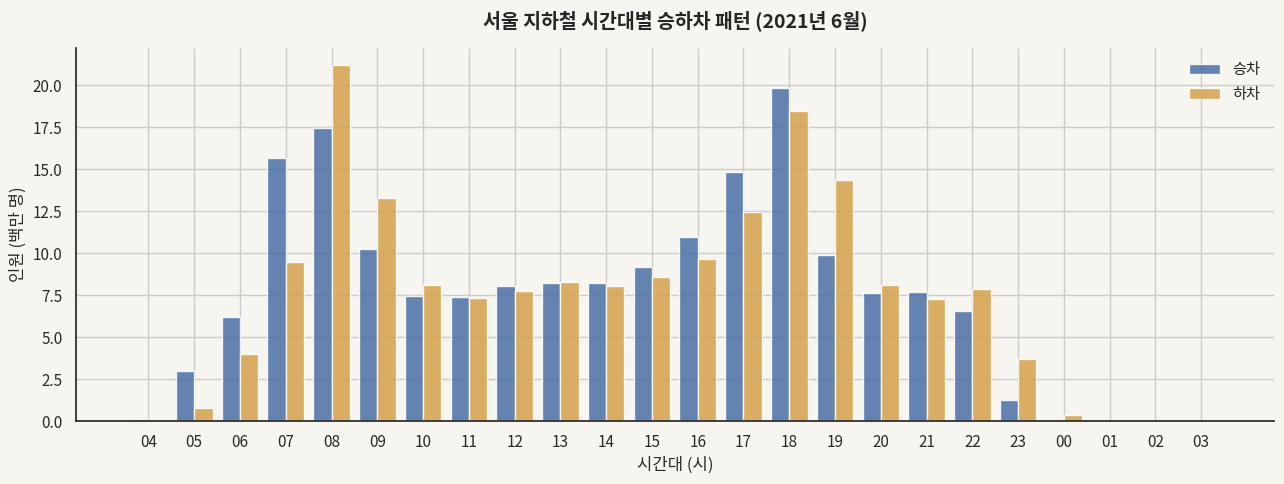


→ 08시(출근)와 18시(퇴근)에 뚜렷한 더블 피크. 상권 분류의 근거가 되는 패턴.


In [7]:
# 시간대별 전체 승하차 패턴 (모든 역 합산)
hourly_board  = ride_jun[board_cols].sum()
hourly_alight = ride_jun[alight_cols].sum()
hours = [c.split("시")[0] for c in board_cols]

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(hours))
ax.bar(x - 0.2, hourly_board.values/1e6,  width=0.4, label="승차", color=COLOR["오피스"], alpha=0.85)
ax.bar(x + 0.2, hourly_alight.values/1e6, width=0.4, label="하차", color=COLOR["복합"], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(hours, rotation=0)
ax.set_xlabel("시간대 (시)"); ax.set_ylabel("인원 (백만 명)")
ax.set_title("서울 지하철 시간대별 승하차 패턴 (2021년 6월)", fontsize=14, weight="bold", pad=15)
ax.legend(loc="upper right", frameon=False)
plt.tight_layout(); plt.show()

print("\n→ 08시(출근)와 18시(퇴근)에 뚜렷한 더블 피크. 상권 분류의 근거가 되는 패턴.")

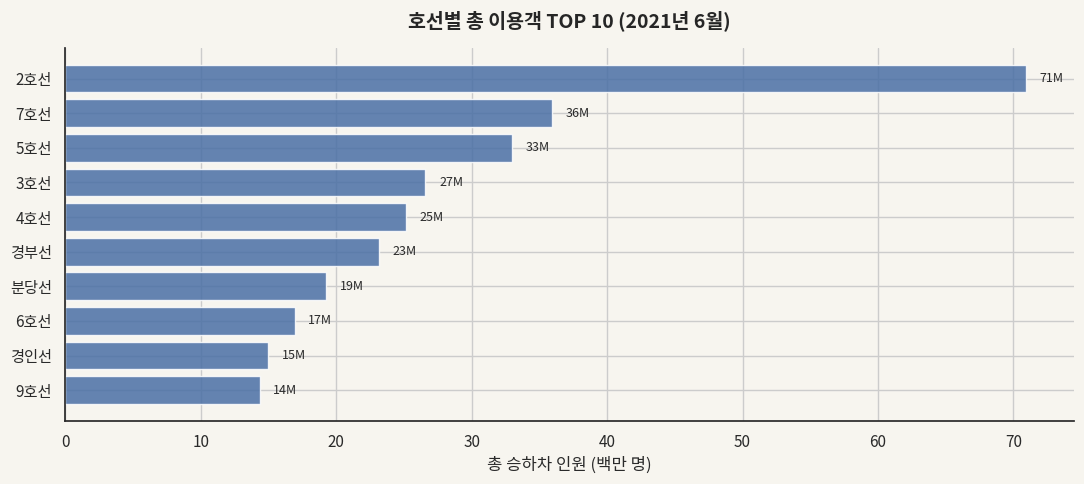

In [8]:
# 호선별 총 이용객 TOP 10
line_total = ride_jun.groupby("호선명")[board_cols + alight_cols].sum().sum(axis=1).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(line_total.index[::-1], line_total.values[::-1]/1e6, color=COLOR["오피스"], alpha=0.85)
ax.set_xlabel("총 승하차 인원 (백만 명)")
ax.set_title("호선별 총 이용객 TOP 10 (2021년 6월)", fontsize=14, weight="bold", pad=15)
for bar, val in zip(bars, line_total.values[::-1]):
    ax.text(val/1e6 + 1, bar.get_y() + bar.get_height()/2, f"{val/1e6:.0f}M", 
            va="center", fontsize=9, color=TEXT)
plt.tight_layout(); plt.show()

## 5. 주거지수 기반 상권 분류

### 핵심 지표: 주거지수(Residential Index)

$$\text{주거지수} = \frac{(\text{출근승차} + \text{퇴근하차}) - (\text{출근하차} + \text{퇴근승차})}{\text{러시아워 총합}}$$

**해석:**
- **+1에 가까울수록 → 주거지역** (아침 떠남, 저녁 돌아옴)
- **-1에 가까울수록 → 오피스지역** (아침 도착, 저녁 떠남)
- **0 근처 → 복합지역** (양쪽 패턴이 균형)

### 분류 임계값
| 구분 | 조건 |
|---|---|
| 주거지역 | 주거지수 ≥ +0.15 |
| 오피스지역 | 주거지수 ≤ -0.15 |
| 복합지역 | -0.15 < 주거지수 < +0.15 |

임계값 ±0.15는 분포 분석 + 알려진 역(강남=오피스, 신림=주거, 잠실=복합)으로 검증한 결과 가장 자연스러운 구분점.

In [9]:
rush_total = stations["출근_승차"] + stations["출근_하차"] + stations["퇴근_승차"] + stations["퇴근_하차"]
res_score  = (stations["출근_승차"] + stations["퇴근_하차"]) - (stations["출근_하차"] + stations["퇴근_승차"])
stations["주거지수"] = res_score / rush_total

def classify(idx):
    if idx >=  0.15: return "주거"
    if idx <= -0.15: return "오피스"
    return "복합"

stations["상권유형"] = stations["주거지수"].apply(classify)

print("=== 상권 유형별 역 개수 ===")
print(stations["상권유형"].value_counts())
print(f"\n주거지수 통계: 평균 {stations['주거지수'].mean():+.3f}, 표준편차 {stations['주거지수'].std():.3f}")

=== 상권 유형별 역 개수 ===
상권유형
주거     296
오피스    124
복합     100
Name: count, dtype: int64

주거지수 통계: 평균 +0.146, 표준편차 0.395


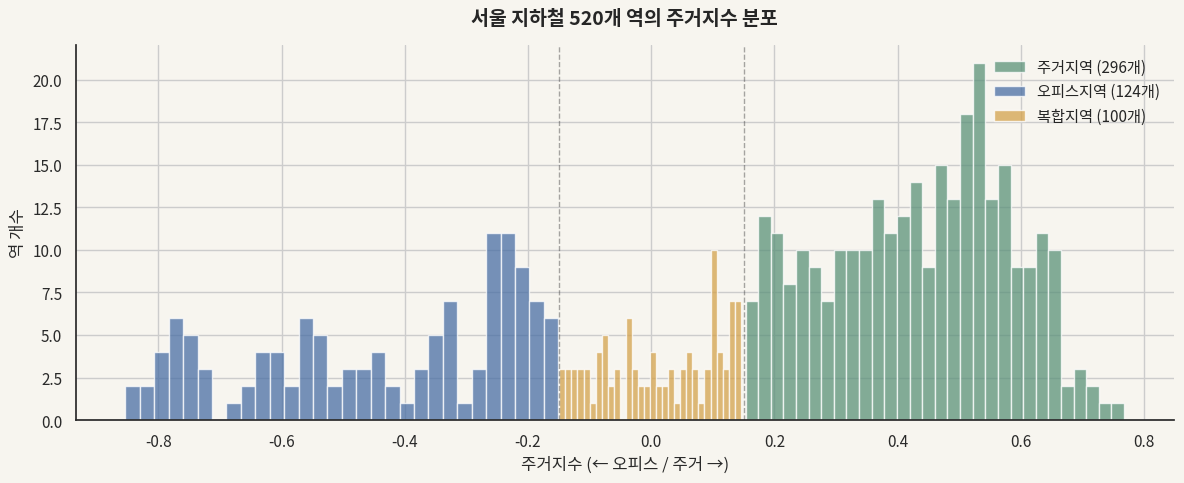

In [10]:
# 주거지수 분포 시각화
fig, ax = plt.subplots(figsize=(12, 5))
for cat, color in COLOR.items():
    subset = stations[stations["상권유형"] == cat]["주거지수"]
    ax.hist(subset, bins=30, alpha=0.75, label=f"{cat}지역 ({len(subset)}개)", color=color)

ax.axvline(-0.15, color=TEXT, linestyle="--", alpha=0.4, linewidth=1)
ax.axvline( 0.15, color=TEXT, linestyle="--", alpha=0.4, linewidth=1)
ax.set_xlabel("주거지수 (← 오피스 / 주거 →)"); ax.set_ylabel("역 개수")
ax.set_title("서울 지하철 520개 역의 주거지수 분포", fontsize=14, weight="bold", pad=15)
ax.legend(loc="upper right", frameon=False)
plt.tight_layout(); plt.show()

## 6. 분류 결과 검증

잘 알려진 역들로 분류가 직관에 부합하는지 확인한다.

In [11]:
# Sanity check: 누구나 아는 역들의 분류
test_stations = ["강남","여의도","을지로입구","서울역","광화문",
                 "신림","상계","수유(강북구청)","노원","사당",
                 "잠실(송파구청)","홍대입구","건대입구","구로디지털단지"]

check = (stations[stations["지하철역"].isin(test_stations)]
         [["지하철역","호선명","상권유형","주거지수","총인원"]]
         .sort_values("주거지수", ascending=False))
print("=== 검증: 직관과 일치하는지 확인 ===")
check.to_string(index=False)
check

=== 검증: 직관과 일치하는지 확인 ===


,지하철역,호선명,상권유형,주거지수,총인원
306,신림,2호선,주거,0.613985,3345113
233,상계,4호선,주거,0.604502,992731
288,수유(강북구청),4호선,주거,0.474294,1818344
94,노원,"4호선, 7호선",주거,0.315982,2162843
217,사당,"2호선, 4호선",주거,0.312867,3256041
25,건대입구,"2호선, 7호선",주거,0.182816,2629272
507,홍대입구,"2호선, 경의선, 공항철도 1호선",복합,0.009991,3740889
421,잠실(송파구청),"2호선, 8호선",복합,-0.036939,4425936
53,구로디지털단지,2호선,복합,-0.072164,3172162
251,서울역,"1호선, 4호선, 경부선, 경의선, 공항철도 1호선",오피스,-0.421617,3779552


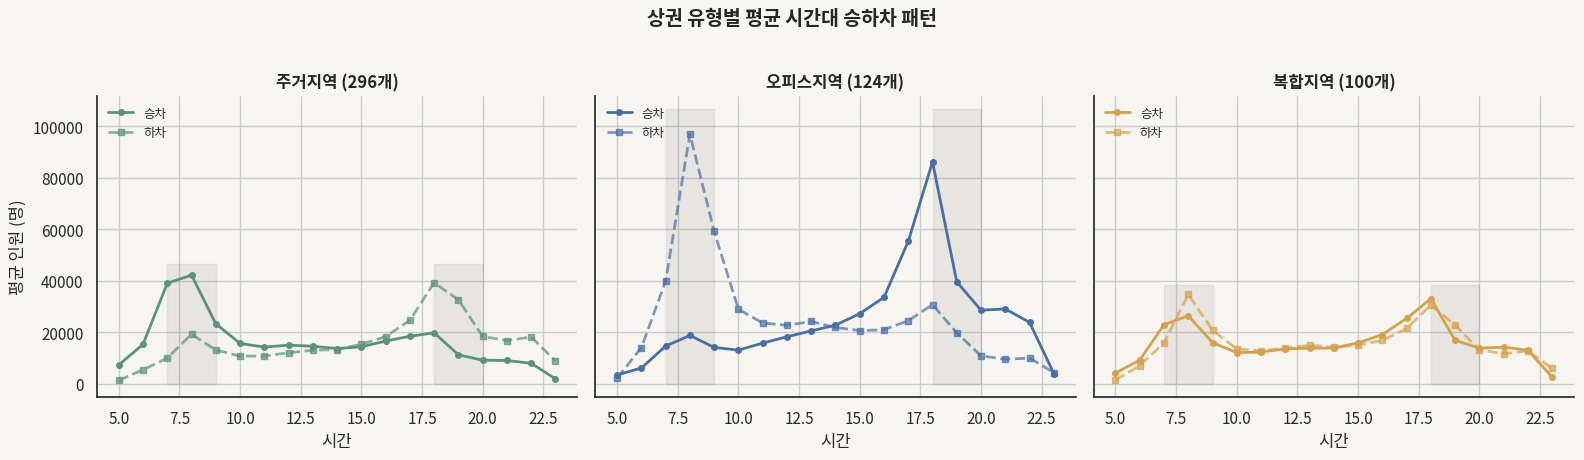

→ 주거지역: 출근시간(07-09시) 승차 우세, 퇴근시간(18-20시) 하차 우세 ✓
→ 오피스지역: 정반대 패턴 (출근=하차, 퇴근=승차) ✓
→ 복합지역: 양쪽 패턴이 모두 나타남 ✓


In [12]:
# 상권 유형별 시간대 평균 패턴 (분류 로직의 타당성 시각화)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

hours_x = list(range(5, 24))  # 05시-24시
for ax, cat in zip(axes, ["주거", "오피스", "복합"]):
    subset = stations[stations["상권유형"] == cat]
    board_avg  = [subset[f"{h:02d}시-{h+1:02d}시 승차인원"].mean() for h in hours_x]
    alight_avg = [subset[f"{h:02d}시-{h+1:02d}시 하차인원"].mean() for h in hours_x]
    
    ax.plot(hours_x, board_avg,  marker="o", color=COLOR[cat], linewidth=2, label="승차", markersize=4)
    ax.plot(hours_x, alight_avg, marker="s", color=COLOR[cat], linewidth=2, label="하차", markersize=4, linestyle="--", alpha=0.7)
    ax.set_title(f"{cat}지역 ({len(subset)}개)", fontsize=12, weight="bold")
    ax.set_xlabel("시간")
    ax.legend(loc="upper left", frameon=False, fontsize=9)
    ax.fill_between([7, 9], 0, max(max(board_avg), max(alight_avg))*1.1, alpha=0.08, color=TEXT)
    ax.fill_between([18, 20], 0, max(max(board_avg), max(alight_avg))*1.1, alpha=0.08, color=TEXT)

axes[0].set_ylabel("평균 인원 (명)")
plt.suptitle("상권 유형별 평균 시간대 승하차 패턴", fontsize=14, weight="bold", y=1.02)
plt.tight_layout(); plt.show()

print("→ 주거지역: 출근시간(07-09시) 승차 우세, 퇴근시간(18-20시) 하차 우세 ✓")
print("→ 오피스지역: 정반대 패턴 (출근=하차, 퇴근=승차) ✓")
print("→ 복합지역: 양쪽 패턴이 모두 나타남 ✓")

In [13]:
# 상권 유형별 TOP 5 역
for cat in ["주거", "오피스", "복합"]:
    top = (stations[stations["상권유형"] == cat]
           .nlargest(5, "총인원")
           [["지하철역","호선명","총인원","주거지수"]])
    print(f"\n■ {cat}지역 TOP 5 (총 유동인구 기준)")
    print(top.to_string(index=False))


■ 주거지역 TOP 5 (총 유동인구 기준)
       지하철역      호선명     총인원     주거지수
         신림      2호선 3345113 0.613985
         사당 2호선, 4호선 3256041 0.312867
        신도림 2호선, 경부선 2869523 0.214647
       건대입구 2호선, 7호선 2629272 0.182816
서울대입구(관악구청)      2호선 2538270 0.455194

■ 오피스지역 TOP 5 (총 유동인구 기준)
   지하철역                          호선명     총인원      주거지수
     강남                          2호선 4381075 -0.451758
  고속터미널                3호선, 7호선, 9호선 3939826 -0.202865
    서울역 1호선, 4호선, 경부선, 경의선, 공항철도 1호선 3779552 -0.421617
     선릉                     2호선, 분당선 3467247 -0.715814
가산디지털단지                     7호선, 경부선 3328842 -0.766738

■ 복합지역 TOP 5 (총 유동인구 기준)
    지하철역                호선명     총인원      주거지수
잠실(송파구청)           2호선, 8호선 4425936 -0.036939
    홍대입구 2호선, 경의선, 공항철도 1호선 3740889  0.009991
 구로디지털단지                2호선 3172162 -0.072164
      수원           경부선, 분당선 2474900  0.118110
      합정           2호선, 6호선 2466578 -0.084491


## 7. 지도 시각화

상권 유형이 서울 안에서 **공간적으로 어떻게 분포**하는지 folium 인터랙티브 지도로 확인.

In [14]:
# folium 인터랙티브 지도
mapped = stations.dropna(subset=["x좌표","y좌표"]).copy()

m = folium.Map(location=[37.55, 126.98], zoom_start=11, tiles="cartodbpositron")

for _, row in mapped.iterrows():
    folium.CircleMarker(
        location=[row["x좌표"], row["y좌표"]],
        radius=max(3, np.log1p(row["총인원"])/2),
        color=COLOR[row["상권유형"]],
        fill=True, fill_opacity=0.7, weight=1,
        popup=folium.Popup(
            f"<b>{row['지하철역']}</b><br>"
            f"호선: {row['호선명']}<br>"
            f"유형: <b style='color:{COLOR[row['상권유형']]}'>{row['상권유형']}</b><br>"
            f"주거지수: {row['주거지수']:+.3f}<br>"
            f"총 유동: {int(row['총인원']):,}명",
            max_width=250
        ),
    ).add_to(m)

# 범례 추가
legend_html = f'''
<div style="position: fixed; bottom: 30px; left: 30px; z-index:9999;
            background:{PAPER_BG}; padding:12px 16px; border-radius:6px;
            border:1px solid #ccc; font-family:sans-serif; font-size:13px;">
  <b>상권 유형</b><br>
  <span style="color:{COLOR['주거']}">●</span> 주거지역<br>
  <span style="color:{COLOR['오피스']}">●</span> 오피스지역<br>
  <span style="color:{COLOR['복합']}">●</span> 복합지역<br>
  <small>원 크기 ∝ log(유동인구)</small>
</div>'''
m.get_root().html.add_child(folium.Element(legend_html))
m

## 8. 팝업 스토어 추천 시스템

### 추천 점수 공식

$$\text{추천점수} = w(\text{브랜드}, \text{상권유형}) \times \log(1 + \text{유동인구})$$

- $w$: 브랜드 카테고리와 상권 유형의 **적합도 가중치** (0.1 ~ 1.0)
- $\log$를 쓰는 이유: **강남·잠실 같은 거대역이 모든 추천을 독점하지 않도록** 보정

### 브랜드 카테고리 매핑 근거

| 카테고리 | 1순위 상권 | 근거 |
|---|---|---|
| 패션/뷰티 | 복합 | 20-30대 유동, 퇴근 후·주말 쇼핑 동선 |
| F&B/디저트카페 | 복합 | 가족·친구 단위, 체류시간 긴 방문 |
| 직장인 타겟 | 오피스 | 출근시간 하차 집중, 점심·퇴근 동선 |
| 키즈/패밀리 | 주거 | 주말·저녁 가족 동선 |
| 라이프스타일/홈 | 주거 | 거주 인구 기반, 실생활 밀착 |
| Z세대/한정판 굿즈 | 복합 | 트렌디 핫스팟, SNS 인증 동선 |
| 헬스/웰니스 | 오피스 | 직장인 점심·퇴근 후 운동 |

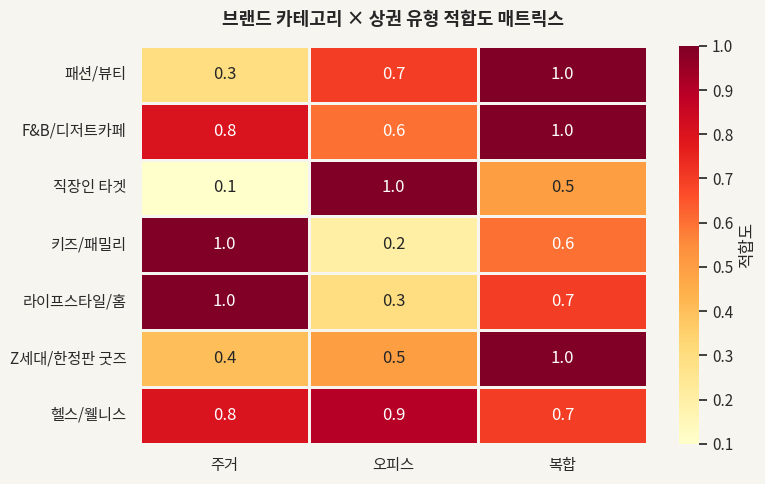

In [15]:
# 브랜드 카테고리 × 상권 유형 적합도 매트릭스
BRAND_WEIGHTS = {
    "패션/뷰티":         {"복합": 1.0, "오피스": 0.7, "주거": 0.3},
    "F&B/디저트카페":    {"복합": 1.0, "주거": 0.8, "오피스": 0.6},
    "직장인 타겟":        {"오피스": 1.0, "복합": 0.5, "주거": 0.1},
    "키즈/패밀리":        {"주거": 1.0, "복합": 0.6, "오피스": 0.2},
    "라이프스타일/홈":    {"주거": 1.0, "복합": 0.7, "오피스": 0.3},
    "Z세대/한정판 굿즈":  {"복합": 1.0, "오피스": 0.5, "주거": 0.4},
    "헬스/웰니스":        {"오피스": 0.9, "주거": 0.8, "복합": 0.7},
}

# 매핑을 히트맵으로 시각화
weight_df = pd.DataFrame(BRAND_WEIGHTS).T[["주거","오피스","복합"]]

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(weight_df, annot=True, fmt=".1f", cmap="YlOrRd", 
            cbar_kws={"label":"적합도"}, linewidths=1, linecolor=PAPER_BG, ax=ax)
ax.set_title("브랜드 카테고리 × 상권 유형 적합도 매트릭스", fontsize=13, weight="bold", pad=15)
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.show()

In [16]:
def recommend(brand_category, top_n=5, verbose=True):
    """브랜드 카테고리를 입력하면 TOP N 추천 역을 반환.
    
    Parameters
    ----------
    brand_category : str
        BRAND_WEIGHTS 키 중 하나
    top_n : int
        반환할 상위 역 개수
    verbose : bool
        True면 출력, False면 DataFrame만 반환
    """
    if brand_category not in BRAND_WEIGHTS:
        raise ValueError(f"지원하지 않는 카테고리: {brand_category}\n"
                         f"선택지: {list(BRAND_WEIGHTS.keys())}")
    
    weights = BRAND_WEIGHTS[brand_category]
    df = stations.copy()
    df["적합도"]   = df["상권유형"].map(weights)
    df["추천점수"] = df["적합도"] * np.log1p(df["총인원"])
    
    result = df.nlargest(top_n, "추천점수")[
        ["지하철역","호선명","상권유형","주거지수","총인원","적합도","추천점수"]
    ].reset_index(drop=True)
    result.index += 1
    
    if verbose:
        print(f"\n{'='*70}")
        print(f" 💡 「{brand_category}」 팝업 스토어 추천 TOP {top_n}")
        print(f"{'='*70}")
        for rank, row in result.iterrows():
            print(f"  {rank}위. {row['지하철역']:14s} ({row['호선명']})")
            print(f"       유형: {row['상권유형']:5s}  주거지수: {row['주거지수']:+.3f}  "
                  f"유동: {int(row['총인원']):>9,}명  점수: {row['추천점수']:.3f}")
        print()
    return result

# 사용 가능한 브랜드 카테고리
print("📋 사용 가능한 브랜드 카테고리:")
for i, k in enumerate(BRAND_WEIGHTS.keys(), 1):
    print(f"  {i}. {k}")

📋 사용 가능한 브랜드 카테고리:
  1. 패션/뷰티
  2. F&B/디저트카페
  3. 직장인 타겟
  4. 키즈/패밀리
  5. 라이프스타일/홈
  6. Z세대/한정판 굿즈
  7. 헬스/웰니스


## 9. 추천 결과 데모

브랜드 카테고리별로 추천 결과를 확인한다.

In [17]:
_ = recommend("패션/뷰티")


 💡 「패션/뷰티」 팝업 스토어 추천 TOP 5
  1위. 잠실(송파구청)       (2호선, 8호선)
       유형: 복합     주거지수: -0.037  유동: 4,425,936명  점수: 15.303
  2위. 홍대입구           (2호선, 경의선, 공항철도 1호선)
       유형: 복합     주거지수: +0.010  유동: 3,740,889명  점수: 15.135
  3위. 구로디지털단지        (2호선)
       유형: 복합     주거지수: -0.072  유동: 3,172,162명  점수: 14.970
  4위. 수원             (경부선, 분당선)
       유형: 복합     주거지수: +0.118  유동: 2,474,900명  점수: 14.722
  5위. 합정             (2호선, 6호선)
       유형: 복합     주거지수: -0.084  유동: 2,466,578명  점수: 14.718



In [18]:
_ = recommend("직장인 타겟")


 💡 「직장인 타겟」 팝업 스토어 추천 TOP 5
  1위. 강남             (2호선)
       유형: 오피스    주거지수: -0.452  유동: 4,381,075명  점수: 15.293
  2위. 고속터미널          (3호선, 7호선, 9호선)
       유형: 오피스    주거지수: -0.203  유동: 3,939,826명  점수: 15.187
  3위. 서울역            (1호선, 4호선, 경부선, 경의선, 공항철도 1호선)
       유형: 오피스    주거지수: -0.422  유동: 3,779,552명  점수: 15.145
  4위. 선릉             (2호선, 분당선)
       유형: 오피스    주거지수: -0.716  유동: 3,467,247명  점수: 15.059
  5위. 가산디지털단지        (7호선, 경부선)
       유형: 오피스    주거지수: -0.767  유동: 3,328,842명  점수: 15.018



In [19]:
_ = recommend("키즈/패밀리")


 💡 「키즈/패밀리」 팝업 스토어 추천 TOP 5
  1위. 신림             (2호선)
       유형: 주거     주거지수: +0.614  유동: 3,345,113명  점수: 15.023
  2위. 사당             (2호선, 4호선)
       유형: 주거     주거지수: +0.313  유동: 3,256,041명  점수: 14.996
  3위. 신도림            (2호선, 경부선)
       유형: 주거     주거지수: +0.215  유동: 2,869,523명  점수: 14.870
  4위. 건대입구           (2호선, 7호선)
       유형: 주거     주거지수: +0.183  유동: 2,629,272명  점수: 14.782
  5위. 서울대입구(관악구청)    (2호선)
       유형: 주거     주거지수: +0.455  유동: 2,538,270명  점수: 14.747



In [20]:
_ = recommend("Z세대/한정판 굿즈")


 💡 「Z세대/한정판 굿즈」 팝업 스토어 추천 TOP 5
  1위. 잠실(송파구청)       (2호선, 8호선)
       유형: 복합     주거지수: -0.037  유동: 4,425,936명  점수: 15.303
  2위. 홍대입구           (2호선, 경의선, 공항철도 1호선)
       유형: 복합     주거지수: +0.010  유동: 3,740,889명  점수: 15.135
  3위. 구로디지털단지        (2호선)
       유형: 복합     주거지수: -0.072  유동: 3,172,162명  점수: 14.970
  4위. 수원             (경부선, 분당선)
       유형: 복합     주거지수: +0.118  유동: 2,474,900명  점수: 14.722
  5위. 합정             (2호선, 6호선)
       유형: 복합     주거지수: -0.084  유동: 2,466,578명  점수: 14.718



### 추천 결과 비교 시각화

3개 카테고리를 한 화면에서 비교해본다.

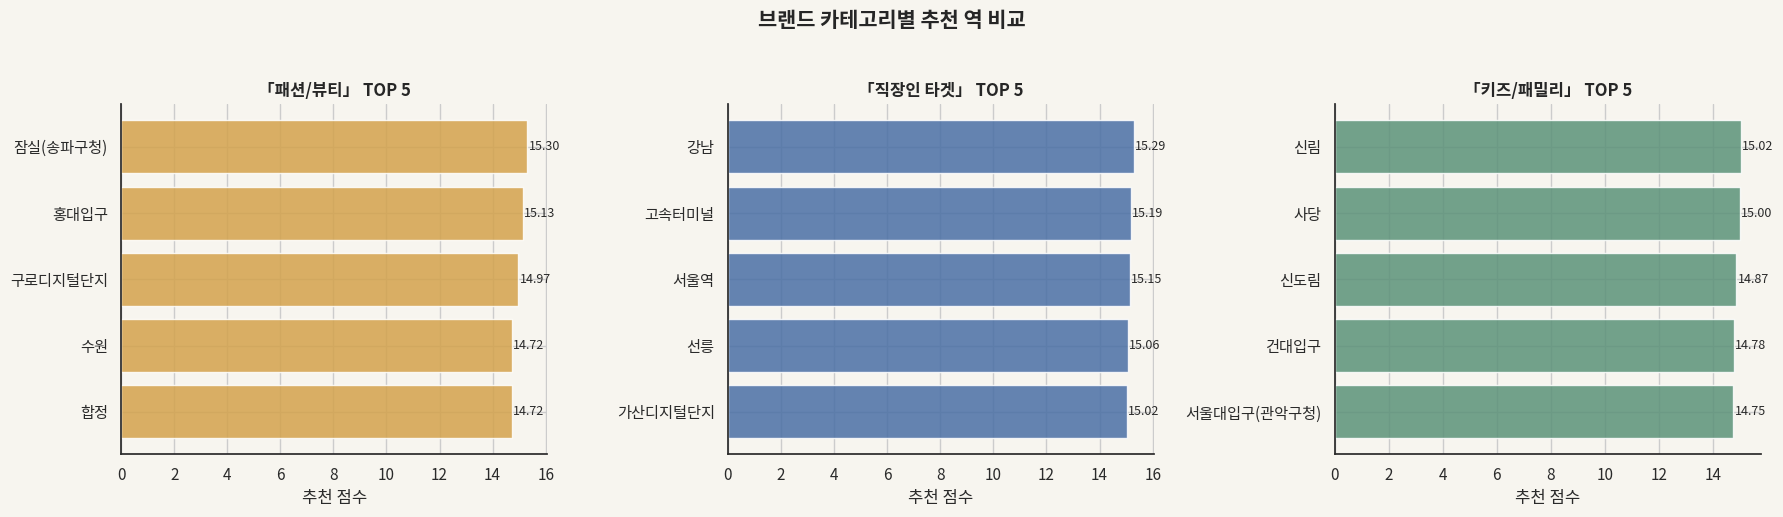

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
demo_brands = ["패션/뷰티", "직장인 타겟", "키즈/패밀리"]

for ax, brand in zip(axes, demo_brands):
    top = recommend(brand, top_n=5, verbose=False)
    bars = ax.barh(top["지하철역"][::-1], top["추천점수"][::-1],
                   color=[COLOR[t] for t in top["상권유형"][::-1]], alpha=0.85)
    ax.set_title(f"「{brand}」 TOP 5", fontsize=12, weight="bold")
    ax.set_xlabel("추천 점수")
    for bar, score in zip(bars, top["추천점수"][::-1]):
        ax.text(score + 0.05, bar.get_y() + bar.get_height()/2, 
                f"{score:.2f}", va="center", fontsize=9, color=TEXT)

plt.suptitle("브랜드 카테고리별 추천 역 비교", fontsize=15, weight="bold", y=1.03)
plt.tight_layout(); plt.show()



In [22]:
# 추천 결과를 지도 위에 표시 (예: 패션/뷰티)
demo_brand = "패션/뷰티"
top5 = recommend(demo_brand, top_n=5, verbose=False)
top5 = top5.merge(stations[["지하철역","x좌표","y좌표"]], on="지하철역", how="left")

m2 = folium.Map(location=[37.55, 126.98], zoom_start=11, tiles="cartodbpositron")

# 배경: 전체 역 (회색 점)
for _, row in mapped.iterrows():
    folium.CircleMarker(
        location=[row["x좌표"], row["y좌표"]], radius=2,
        color="#cccccc", fill=True, fill_opacity=0.4, weight=0,
    ).add_to(m2)

# 추천 TOP 5 강조 (큰 별 마커)
for rank, row in top5.iterrows():
    folium.Marker(
        location=[row["x좌표"], row["y좌표"]],
        popup=f"<b>{rank}위: {row['지하철역']}</b><br>점수: {row['추천점수']:.2f}",
        icon=folium.Icon(color="red", icon="star", prefix="fa"),
    ).add_to(m2)

print(f"🗺️  「{demo_brand}」 추천 TOP 5 위치")
m2

🗺️  「패션/뷰티」 추천 TOP 5 위치


## 10. 인사이트 & 한계점

### 주요 인사이트

1. **상권은 시간대 패턴으로 분리된다.** 출퇴근 시간대의 승하차 비율 하나만으로 상권 유형을 신뢰성 있게 구분할 수 있음 (520개 역 전수 검증).

2. **카테고리별 추천 상위권이 명확히 갈린다.** 패션/뷰티는 잠실·홍대입구 같은 복합 상권에, 직장인 타겟은 강남·고속터미널·서울역 등 오피스 상권에, 키즈/패밀리는 신림·사당·신도림 등 주거 상권에 자연스럽게 집중.

3. **로그 보정의 효과.** 단순 유동인구 순위로는 모든 카테고리에서 강남·잠실이 상위를 독점하지만, $\log$ 보정 + 카테고리별 가중치로 **상권 적합도와 트래픽 규모의 균형**을 잡을 수 있다.

### 한계와 보완 방향

| 한계점 | 보완 방법 |
|---|---|
| 월 합계 데이터 → 평일/주말 구분 불가 | 일별 데이터 확보 시 평일·주말 분리 분석 |
| 유동인구 ≠ 실제 구매력 | 카드사 매출 데이터, 상권 평균 객단가 결합 |
| 임대료·공실률 미반영 | 부동산 공시 데이터, 상가 임대료 지표 추가 |
| 브랜드 가중치는 정성적 판단 | 실제 팝업 매출 데이터로 가중치 학습 (지도학습) |
| COVID-19 영향이 남은 시점 | 최신(2024+) 데이터 재분석 필요 |

### 발전 방향

- **클러스터링 기반 세분화**: 주거/오피스/복합 3개 분류를 K-means로 5~7개 미세 카테고리로 확장
- **시계열 비교**: COVID-19 전후 상권 변화 분석
- **다른 도시 적용**: 부산·인천 지하철 데이터로 일반화 검증
- **외부 데이터 통합**: 상권별 점포 구성(요식업/소매업 비율), 카드 매출 데이터

---

## 프로젝트 요약

| 항목 | 내용 |
|---|---|
| 분석 데이터 | 서울 지하철 520개 역 × 24시간 승하차 (2021년 6월) |
| 분류 방법 | 주거지수 기반 룰베이스 분류 (±0.15 임계값) |
| 추천 모델 | 적합도 가중치 × log(유동인구) |
| 핵심 산출물 | 브랜드 카테고리별 TOP N 추천 함수 |
| 시각화 | matplotlib (정적) + folium (인터랙티브 지도) |

> "감"으로 정하던 입지 선정을, **데이터가 뒷받침하는 의사결정**으로 바꾸는 첫 걸음.